# Lab 5 Water Quality Analysis

This notebook implements the airborne workflow, Sentinel-2 acquisition,
cross-sensor comparison, and the SAM plus calibration phase of the Lab 5
pipeline. It loads one ENVI scene, derives airborne water-quality products,
prepares the closest Sentinel-2 scene for the same footprint, and compares both
sources on a shared grid before applying spectral-angle classification.


In [62]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)

if (Path.cwd() / "src").exists():
    REPO_ROOT = Path.cwd()
else:
    REPO_ROOT = Path.cwd().parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.lab5.envi_utils import (
    build_invalid_band_mask,
    find_nearest_band,
    get_ignore_value,
    get_rgb_bands,
    load_envi_image,
    parse_wavelengths,
    read_rgb,
)
from src.lab5.indices import (
    band_by_wavelength,
    chlorophyll_red_edge_peak,
    composite_by_wavelengths,
    doc_proxy_green_red,
    ndci,
    ndti,
    stretch_composite,
)
from src.lab5.sentinel2 import (
    SENTINEL2_REQUIRED_BANDS,
    align_array_to_grid,
    build_overlap_mask,
    comparison_output_dir,
    describe_item,
    download_band,
    find_cached_band_files,
    load_local_stack,
    open_catalog,
    scene_bbox_wgs84_from_envi,
    scene_grid_from_envi,
    search_s2_items,
    select_best_item,
    summarize_pair,
)
from src.lab5.sam import (
    SENTINEL2_SAM_BANDS,
    align_reference_to_wavelengths,
    apply_bandwise_linear_calibration,
    fit_bandwise_linear_calibration,
    load_library_summaries,
    resample_airborne_spectrum_to_s2,
    sam_classification,
    spectral_angle_image,
    stack_named_bands,
)

SCENE_PATH = REPO_ROOT / "data/images/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr"
SPECTRAL_LIBRARY_DIR = REPO_ROOT / "data/spectral_library"
SENTINEL2_DIR = REPO_ROOT / "data/sentinel2"
OUTPUTS_ROOT = REPO_ROOT / "data/outputs"
TARGET_DATE = "2025-06-17"
S2_DAY_WINDOW = 5
S2_CLOUD_LIMIT = 20.0

SCENE_PATH


PosixPath('/Users/ernest.molczan/PycharmProjects/eolabs-clone/lab_5/data/images/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr')

## Scene Summary

The first step is to open the hyperspectral scene, read the wavelength metadata,
mark invalid bands, and resolve the nearest usable airborne bands for the Lab 5
products.


In [63]:
img = load_envi_image(SCENE_PATH)
meta = img.metadata
wavelengths = parse_wavelengths(meta)
ignore_value = get_ignore_value(meta)
invalid_mask = build_invalid_band_mask(meta)
rgb_default = read_rgb(img, get_rgb_bands(meta), ignore_value)

def resolve_target(target_nm: float) -> tuple[int, float]:
    # Do not filter by invalid_mask — the "bad" bands in the O2-A absorption
    # region (689-737 nm) contain usable reflectance data for index computation.
    band_index = find_nearest_band(wavelengths, target_nm)
    return band_index, float(wavelengths[band_index])

target_lookup = {
    target_nm: resolve_target(target_nm)
    for target_nm in (490, 560, 665, 705, 740, 842, 1610)
}

metadata_summary = pd.DataFrame([
    {
        "scene_id": SCENE_PATH.stem,
        "rows": img.nrows,
        "cols": img.ncols,
        "bands": img.nbands,
        "ignore_value": ignore_value,
        "invalid_band_count": int(invalid_mask.sum()) if invalid_mask is not None else 0,
        "wavelength_count": int(len(wavelengths)) if wavelengths is not None else 0,
    }
])

band_summary = pd.DataFrame(
    [
        {
            "target_nm": target_nm,
            "band_index": band_index,
            "actual_wavelength_nm": actual_wavelength,
        }
        for target_nm, (band_index, actual_wavelength) in sorted(target_lookup.items())
    ]
    
)

display(metadata_summary)
display(band_summary)


,scene_id,rows,cols,bands,ignore_value,invalid_band_count,wavelength_count
0,221000_Odra_HS_Blok_A_008_VS_join_atm,4300,2001,456,15000.0,155,456


,target_nm,band_index,actual_wavelength_nm
0,490,24,490.85
1,560,46,561.17
2,665,78,663.46
3,705,91,705.02
4,740,102,740.18
5,842,134,842.47
6,1610,292,1612.08


## Natural And False-Color Composites

The natural RGB comes from the ENVI `default bands` metadata. The false-color
composites below follow the Lab 5 execution plan:

- vegetation composite: `842 / 665 / 560`
- moisture composite: `1610 / 842 / 665`
- water-focused composite: `705 / 560 / 490`


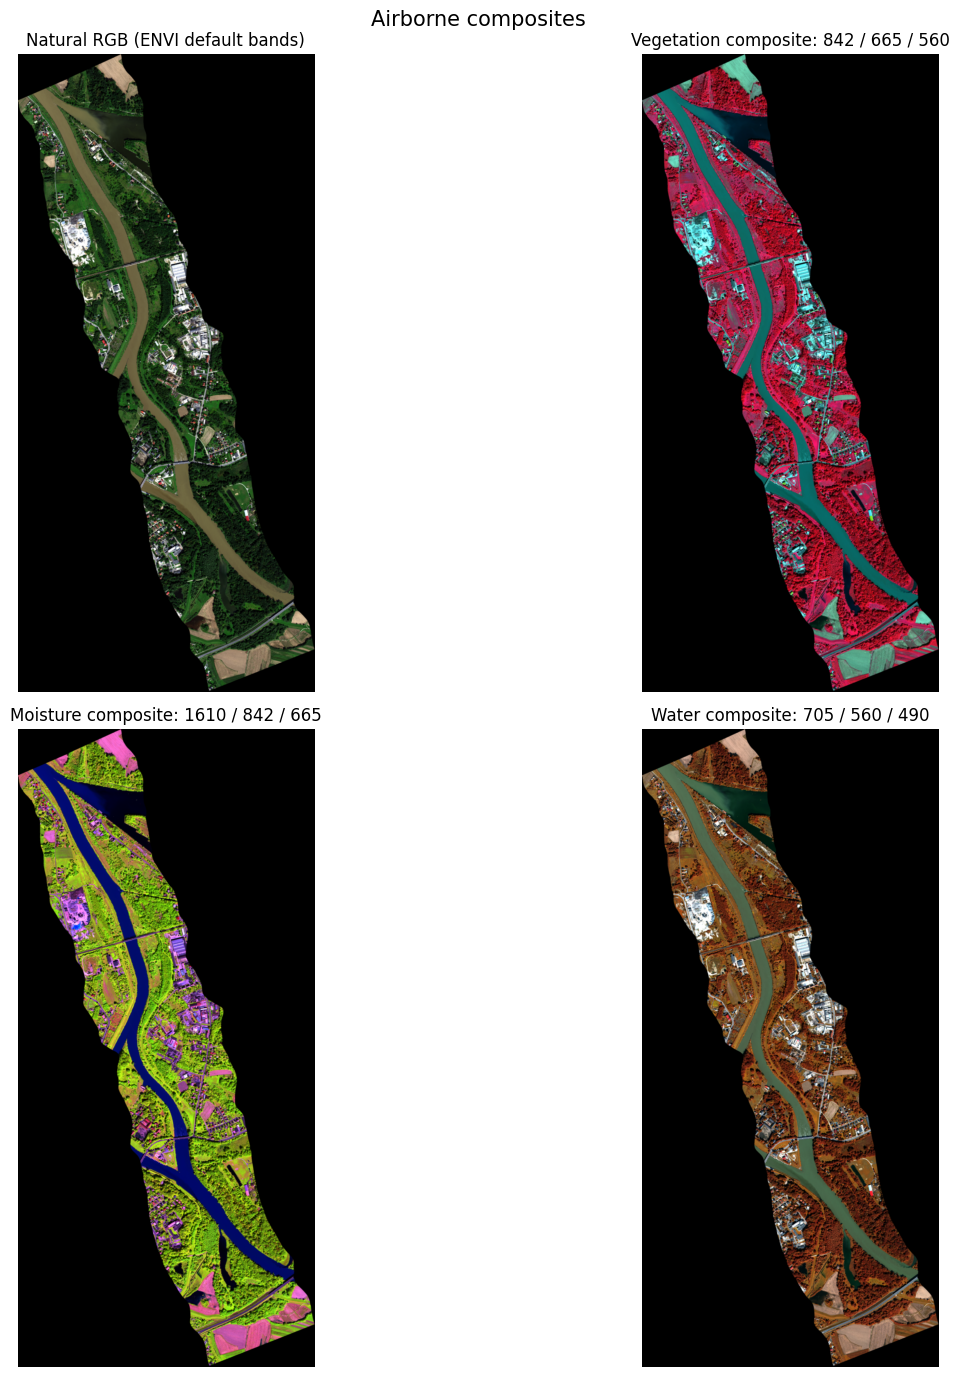

In [64]:
vegetation_rgb = stretch_composite(
    composite_by_wavelengths(
        img,
        wavelengths,
        (842, 665, 560),
        invalid_mask=invalid_mask,
        ignore_value=ignore_value,
    )
)
moisture_rgb = stretch_composite(
    composite_by_wavelengths(
        img,
        wavelengths,
        (1610, 842, 665),
        invalid_mask=invalid_mask,
        ignore_value=ignore_value,
    )
)
water_rgb = stretch_composite(
    composite_by_wavelengths(
        img,
        wavelengths,
        (705, 560, 490),
        # No invalid_mask — the 705 nm band in the O2-A gap has usable reflectance.
        ignore_value=ignore_value,
    )
)

fig, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw={"aspect": "auto"})
fig.suptitle("Airborne composites", fontsize=15)

axes[0, 0].imshow(rgb_default, interpolation="bilinear")
axes[0, 0].set_title("Natural RGB (ENVI default bands)")
axes[0, 0].axis("off")

axes[0, 1].imshow(vegetation_rgb, interpolation="bilinear")
axes[0, 1].set_title("Vegetation composite: 842 / 665 / 560")
axes[0, 1].axis("off")

axes[1, 0].imshow(moisture_rgb, interpolation="bilinear")
axes[1, 0].set_title("Moisture composite: 1610 / 842 / 665")
axes[1, 0].axis("off")

axes[1, 1].imshow(water_rgb, interpolation="bilinear")
axes[1, 1].set_title("Water composite: 705 / 560 / 490")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Airborne Water-Quality Index Maps

This section computes the airborne-only Lab 5 products implemented in
`src/lab5/indices.py`.


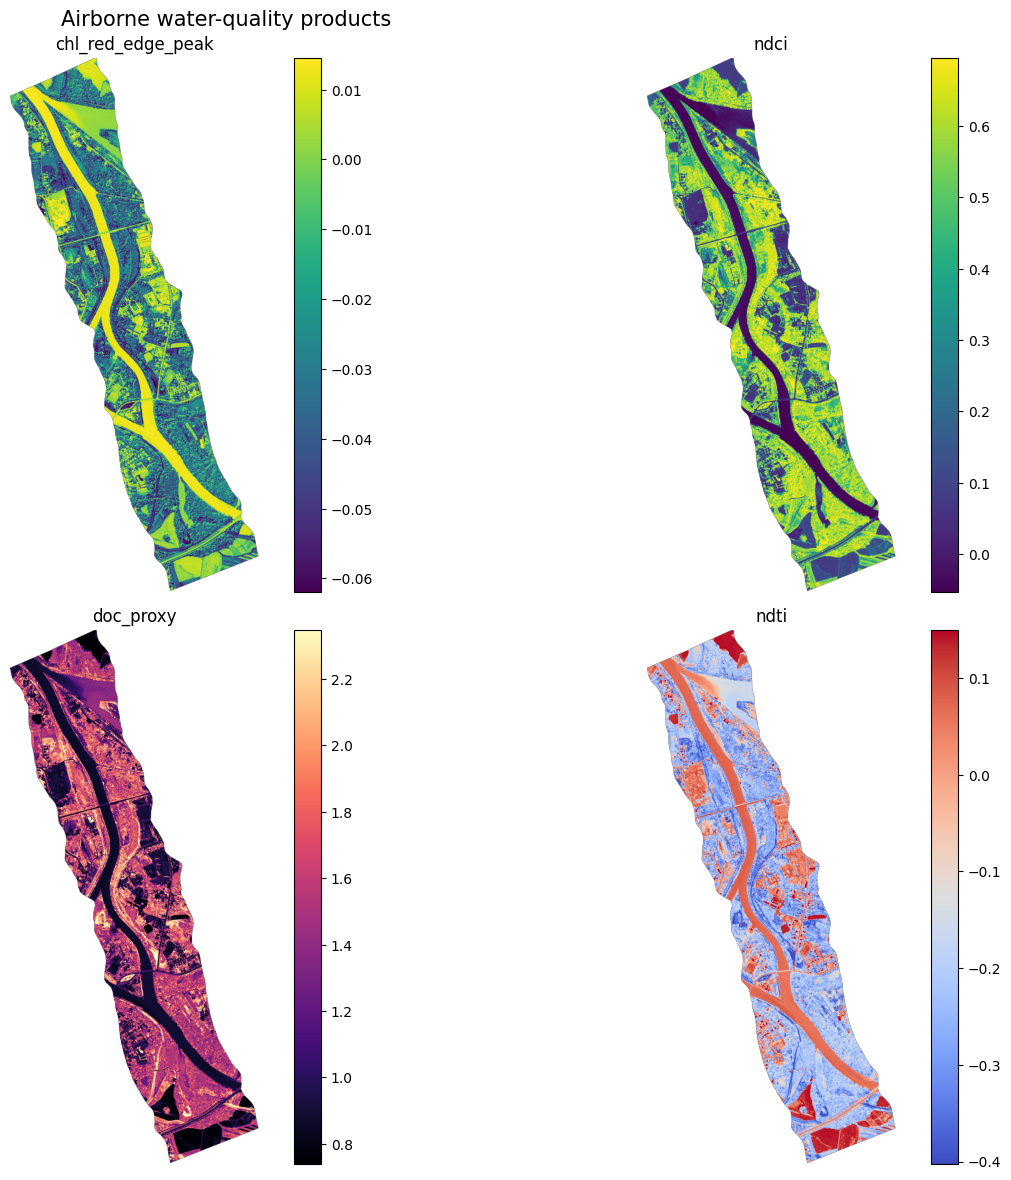

,index,valid_pixels,mean,std,p05,median,p95
0,chl_red_edge_peak,3174220,-0.019681,0.024963,-0.056060,-0.020580,0.013287
1,ndci,3174220,0.366356,0.261344,-0.042136,0.462851,0.674560
2,doc_proxy,3174220,1.386396,0.446843,0.780269,1.414966,2.140762
3,ndti,3174220,-0.131950,0.163333,-0.363212,-0.171831,0.123426


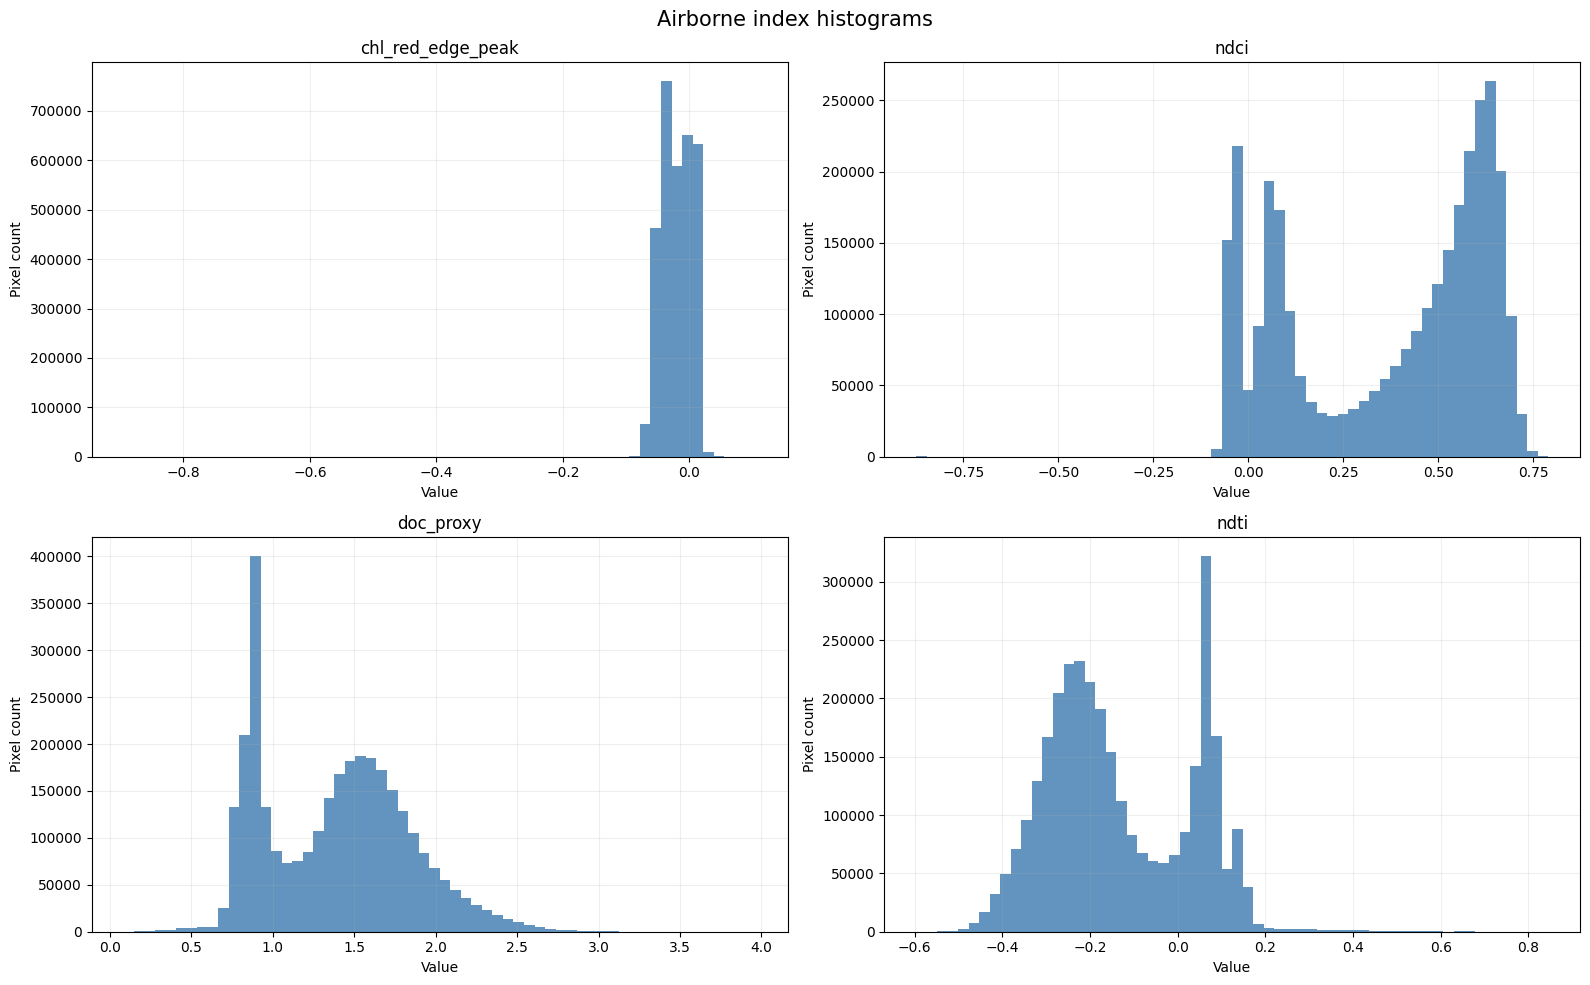

In [65]:
# Do not filter by invalid_mask — the "bad" bands in the O2-A absorption
# region (689-737 nm) contain usable reflectance data for ratio-based indices.
r560 = band_by_wavelength(img, wavelengths, 560, ignore_value=ignore_value)
r665 = band_by_wavelength(img, wavelengths, 665, ignore_value=ignore_value)
r705 = band_by_wavelength(img, wavelengths, 705, ignore_value=ignore_value)
r740 = band_by_wavelength(img, wavelengths, 740, ignore_value=ignore_value)

index_maps = {
    "chl_red_edge_peak": chlorophyll_red_edge_peak(r665, r705, r740),
    "ndci": ndci(r665, r705),
    "doc_proxy": doc_proxy_green_red(r560, r665),
    "ndti": ndti(r560, r665),
}

display_cmaps = {
    "chl_red_edge_peak": "viridis",
    "ndci": "viridis",
    "doc_proxy": "magma",
    "ndti": "coolwarm",
}

def finite_limits(array: np.ndarray) -> tuple[float, float]:
    values = np.asarray(array)[np.isfinite(array)]
    if values.size == 0:
        return -1.0, 1.0
    lo, hi = np.percentile(values, [2, 98])
    if lo == hi:
        return float(lo - 1e-6), float(hi + 1e-6)
    return float(lo), float(hi)

fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={"aspect": "auto"})
fig.suptitle("Airborne water-quality products", fontsize=15)

for ax, (name, array) in zip(axes.flat, index_maps.items(), strict=True):
    lo, hi = finite_limits(array)
    image = ax.imshow(array, cmap=display_cmaps[name], vmin=lo, vmax=hi)
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

airborne_index_stats = pd.DataFrame(
    [
        {
            "index": name,
            "valid_pixels": int(values.size),
            "mean": float(np.mean(values)) if values.size else np.nan,
            "std": float(np.std(values)) if values.size else np.nan,
            "p05": float(np.percentile(values, 5)) if values.size else np.nan,
            "median": float(np.percentile(values, 50)) if values.size else np.nan,
            "p95": float(np.percentile(values, 95)) if values.size else np.nan,
        }
        for name, array in index_maps.items()
        for values in [array[np.isfinite(array)]]
    ]
)
display(airborne_index_stats)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Airborne index histograms", fontsize=15)

for ax, (name, array) in zip(axes.flat, index_maps.items(), strict=True):
    values = array[np.isfinite(array)]
    ax.hist(values, bins=60, color="steelblue", alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel("Value")
    ax.set_ylabel("Pixel count")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


## Sentinel-2 Search And Local Cache

This section converts the airborne footprint to WGS84, searches the Planetary
Computer STAC catalog near `2025-06-17`, and also checks whether a complete local
band cache already exists.


In [66]:
target_grid = scene_grid_from_envi(meta)
scene_bbox_wgs84 = scene_bbox_wgs84_from_envi(meta)
selected_item_summary = None

try:
    catalog = open_catalog()
    s2_items = search_s2_items(
        scene_bbox_wgs84,
        TARGET_DATE,
        day_window=S2_DAY_WINDOW,
        cloud_limit=S2_CLOUD_LIMIT,
        catalog=catalog,
    )
    s2_candidates = pd.DataFrame([describe_item(item, TARGET_DATE) for item in s2_items])
    s2_item = select_best_item(s2_items, TARGET_DATE)
    selected_item_summary = describe_item(s2_item, TARGET_DATE)
except Exception as exc:
    s2_items = []
    s2_candidates = pd.DataFrame()
    s2_item = None
    print(f"Live Sentinel-2 search unavailable in this environment: {exc}")

cached_band_files = find_cached_band_files(
    SENTINEL2_DIR,
    item_id=s2_item.id if s2_item is not None else None,
)
if not cached_band_files and s2_item is None:
    cached_band_files = find_cached_band_files(SENTINEL2_DIR)

if not s2_candidates.empty:
    display(s2_candidates)
if selected_item_summary is not None:
    display(pd.DataFrame([selected_item_summary]))

if cached_band_files:
    cached_table = pd.DataFrame(
        [
            {"band": band_name, "cached_path": str(path)}
            for band_name, path in cached_band_files.items()
        ]
    )
    display(cached_table)
else:
    print("No complete local Sentinel-2 cache found yet.")


,id,datetime,days_from_target,eo_cloud_cover,platform,mgrs_tile
0,S2C_MSIL2A_20250615T095051_R079_T33UYR_2025061...,2025-06-15T09:50:51.025000+00:00,2,0.461973,Sentinel-2C,33UYR
1,S2B_MSIL2A_20250613T100029_R122_T33UYR_2025061...,2025-06-13T10:00:29.025000+00:00,4,1.484568,Sentinel-2B,33UYR


,id,datetime,days_from_target,eo_cloud_cover,platform,mgrs_tile
0,S2C_MSIL2A_20250615T095051_R079_T33UYR_2025061...,2025-06-15T09:50:51.025000+00:00,2,0.461973,Sentinel-2C,33UYR


,band,cached_path
0,B02,/Users/ernest.molczan/PycharmProjects/eolabs-c...
1,B03,/Users/ernest.molczan/PycharmProjects/eolabs-c...
2,B04,/Users/ernest.molczan/PycharmProjects/eolabs-c...
3,B05,/Users/ernest.molczan/PycharmProjects/eolabs-c...
4,B06,/Users/ernest.molczan/PycharmProjects/eolabs-c...
5,B07,/Users/ernest.molczan/PycharmProjects/eolabs-c...
6,B08,/Users/ernest.molczan/PycharmProjects/eolabs-c...
7,B8A,/Users/ernest.molczan/PycharmProjects/eolabs-c...
8,B11,/Users/ernest.molczan/PycharmProjects/eolabs-c...
9,B12,/Users/ernest.molczan/PycharmProjects/eolabs-c...


## Sentinel-2 Band Download And Local Load

If a live STAC item is available, this cell downloads and reprojects the required
Sentinel-2 bands to the airborne grid. If not, it falls back to the most relevant
complete local cache.


In [67]:
if s2_item is not None:
    SENTINEL2_DIR.mkdir(parents=True, exist_ok=True)
    s2_band_files = {
        band_name: download_band(s2_item, band_name, SENTINEL2_DIR, target_grid)
        for band_name in SENTINEL2_REQUIRED_BANDS
    }
else:
    s2_band_files = cached_band_files

if not s2_band_files:
    print("Skipping Sentinel-2 stack load because no live item or cached band set is available.")
    s2_stack = {}
else:
    s2_stack = load_local_stack(s2_band_files)
    download_table = pd.DataFrame(
        [
            {
                "band": band_name,
                "path": str(path),
                "shape": tuple(s2_stack[band_name].shape),
            }
            for band_name, path in s2_band_files.items()
        ]
    )
    display(download_table)


,band,path,shape
0,B02,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
1,B03,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
2,B04,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
3,B05,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
4,B06,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
5,B07,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
6,B08,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
7,B8A,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
8,B11,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
9,B12,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"


## Cross-Sensor Alignment And Overlap

The comparison grid is the shared airborne scene grid already used for the
Sentinel-2 cache. Airborne products are aligned to that grid, Sentinel-2 products
are computed on the same grid, and the overlap mask keeps only pixels that are
valid in both sources.


,source,product,shape
0,airborne,chl_red_edge_peak,"(4300, 2001)"
1,airborne,ndci,"(4300, 2001)"
2,airborne,doc_proxy,"(4300, 2001)"
3,airborne,ndti,"(4300, 2001)"
4,sentinel2,chl_red_edge_peak,"(4300, 2001)"
5,sentinel2,ndci,"(4300, 2001)"
6,sentinel2,doc_proxy,"(4300, 2001)"
7,sentinel2,ndti,"(4300, 2001)"


,valid_overlap_pixels,total_pixels,coverage_fraction
0,3174220,8604300,0.368911


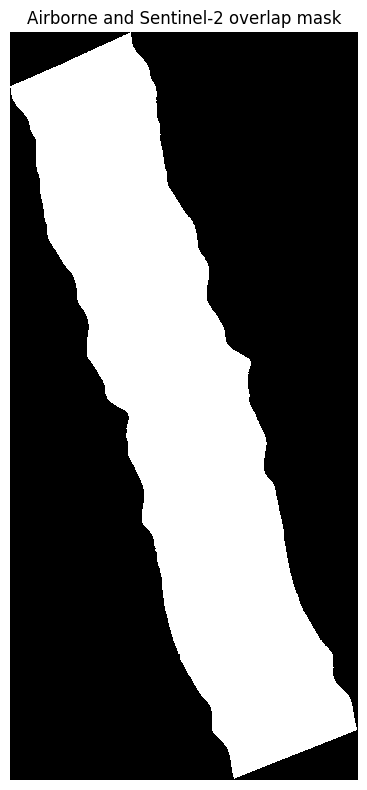

In [68]:
comparison_grid = target_grid
airborne_products = {
    name: align_array_to_grid(array, target_grid, comparison_grid)
    for name, array in index_maps.items()
}

if not s2_stack:
    s2_reflectance = {}
    sentinel_products = {}
    overlap_mask = np.zeros((comparison_grid.height, comparison_grid.width), dtype=bool)
    print("Skipping comparison setup because Sentinel-2 data is unavailable.")
else:
    s2_reflectance = {
        band_name: np.where(np.asarray(array, dtype=np.float32) > 0.0, np.asarray(array, dtype=np.float32), np.nan)
        for band_name, array in s2_stack.items()
    }
    sentinel_products = {
        "chl_red_edge_peak": chlorophyll_red_edge_peak(
            s2_reflectance["B04"],
            s2_reflectance["B05"],
            s2_reflectance["B06"],
        ),
        "ndci": ndci(s2_reflectance["B04"], s2_reflectance["B05"]),
        "doc_proxy": doc_proxy_green_red(s2_reflectance["B03"], s2_reflectance["B04"]),
        "ndti": ndti(s2_reflectance["B03"], s2_reflectance["B04"]),
    }
    overlap_mask = build_overlap_mask(airborne_products, sentinel_products)

    shape_table = pd.DataFrame(
        [
            {"source": "airborne", "product": name, "shape": tuple(array.shape)}
            for name, array in airborne_products.items()
        ]
        + [
            {"source": "sentinel2", "product": name, "shape": tuple(array.shape)}
            for name, array in sentinel_products.items()
        ]
    )
    overlap_summary = pd.DataFrame(
        [
            {
                "valid_overlap_pixels": int(overlap_mask.sum()),
                "total_pixels": int(overlap_mask.size),
                "coverage_fraction": float(overlap_mask.mean()),
            }
        ]
    )
    display(shape_table)
    display(overlap_summary)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(overlap_mask, cmap="gray", interpolation="nearest")
    ax.set_title("Airborne and Sentinel-2 overlap mask")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


## Cross-Sensor Comparison Outputs

This section applies the overlap mask to every comparison plot, computes summary
statistics, and saves the maps, histograms, scatter plots, and CSV table under
`data/outputs/comparison/<scene_id>/`.


,index,valid_pixels,airborne_mean,sentinel_mean,bias_s2_minus_airborne,mae,rmse,pearson_r
0,chl_red_edge_peak,3174220,-0.019681,-0.051085,-0.031404,0.034950,0.043644,0.506278
1,ndci,3174220,0.366356,0.159910,-0.206446,0.251384,0.299139,0.705316
2,doc_proxy,3174220,1.386396,1.131338,-0.255058,0.397087,0.495118,0.343696
3,ndti,3174220,-0.131950,-0.059891,0.072059,0.145653,0.169189,0.367973


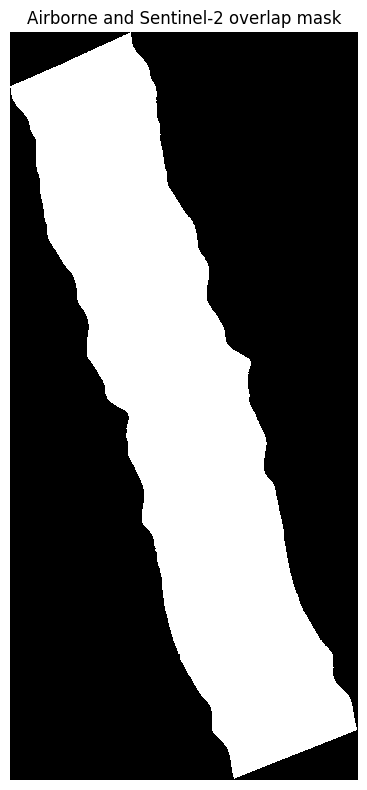

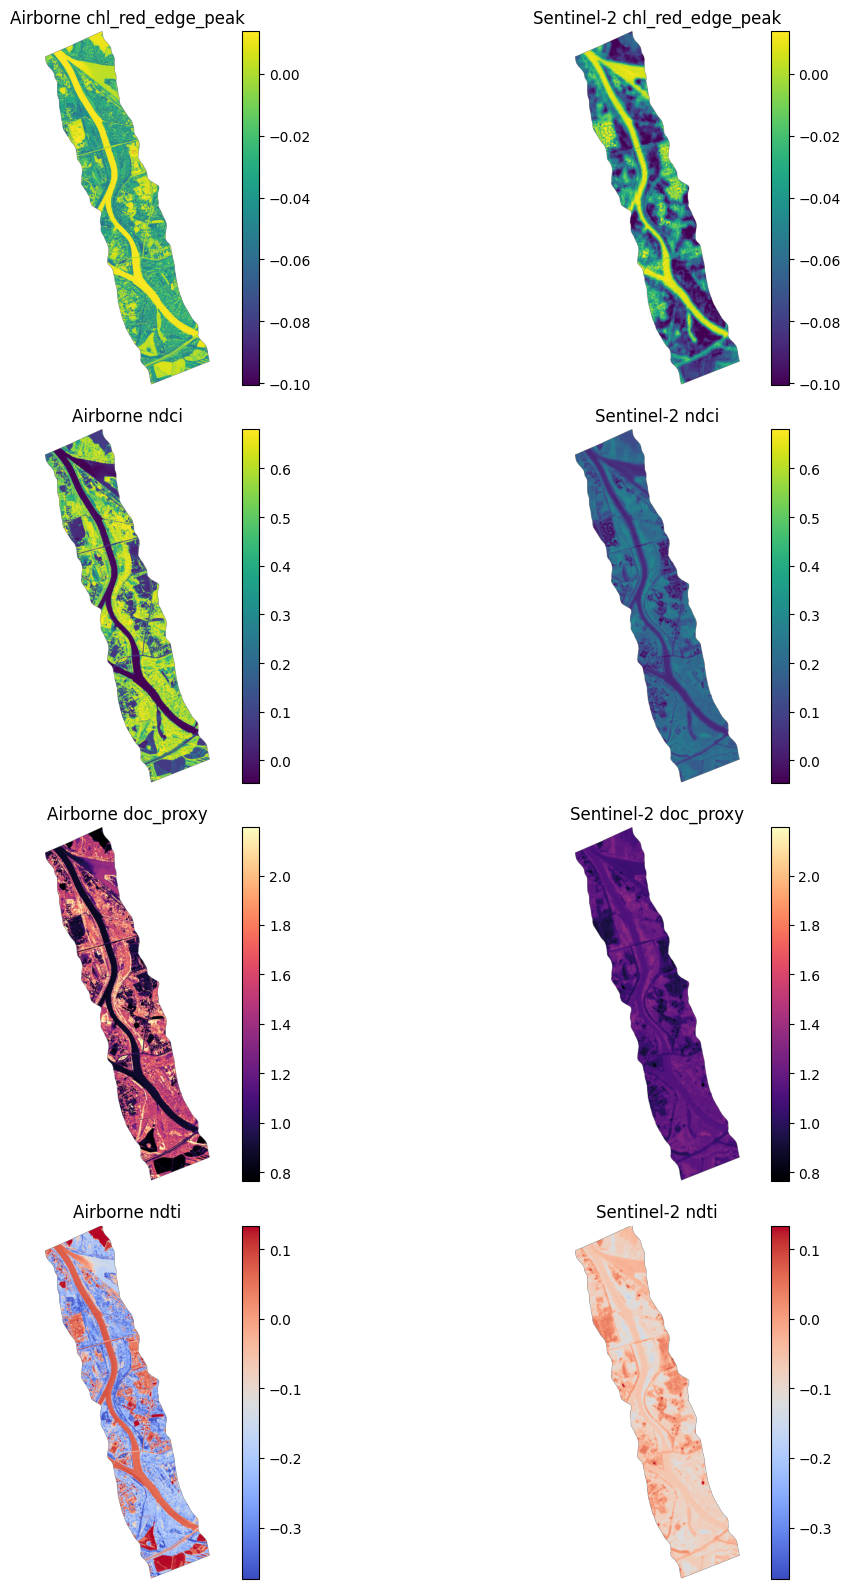

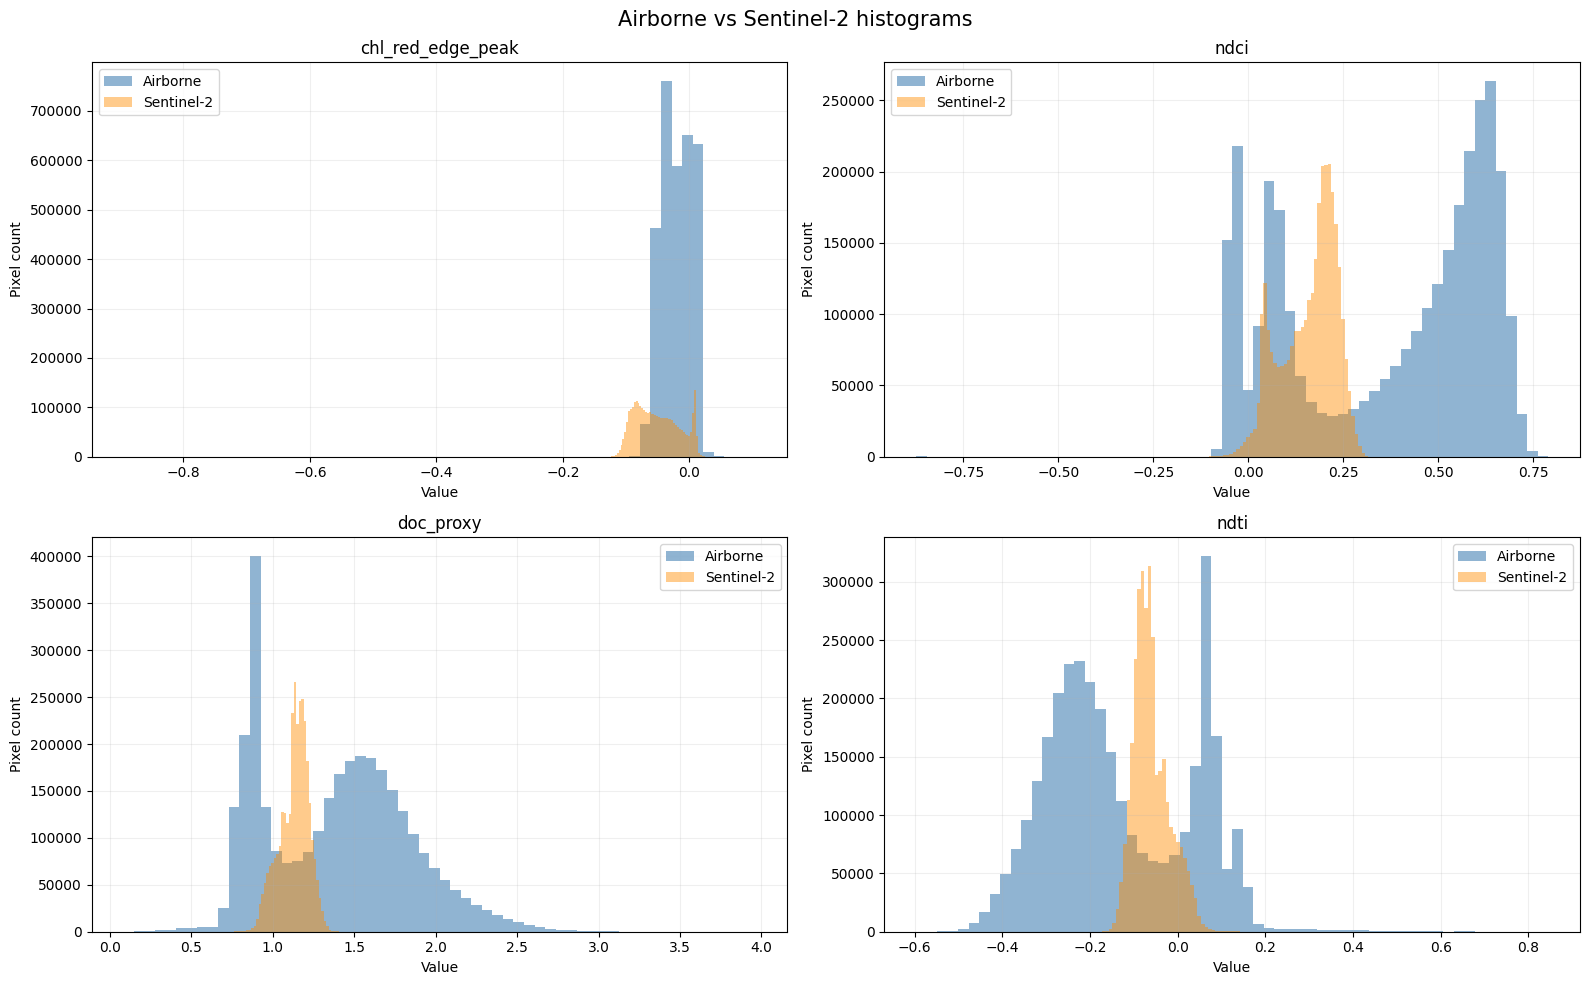

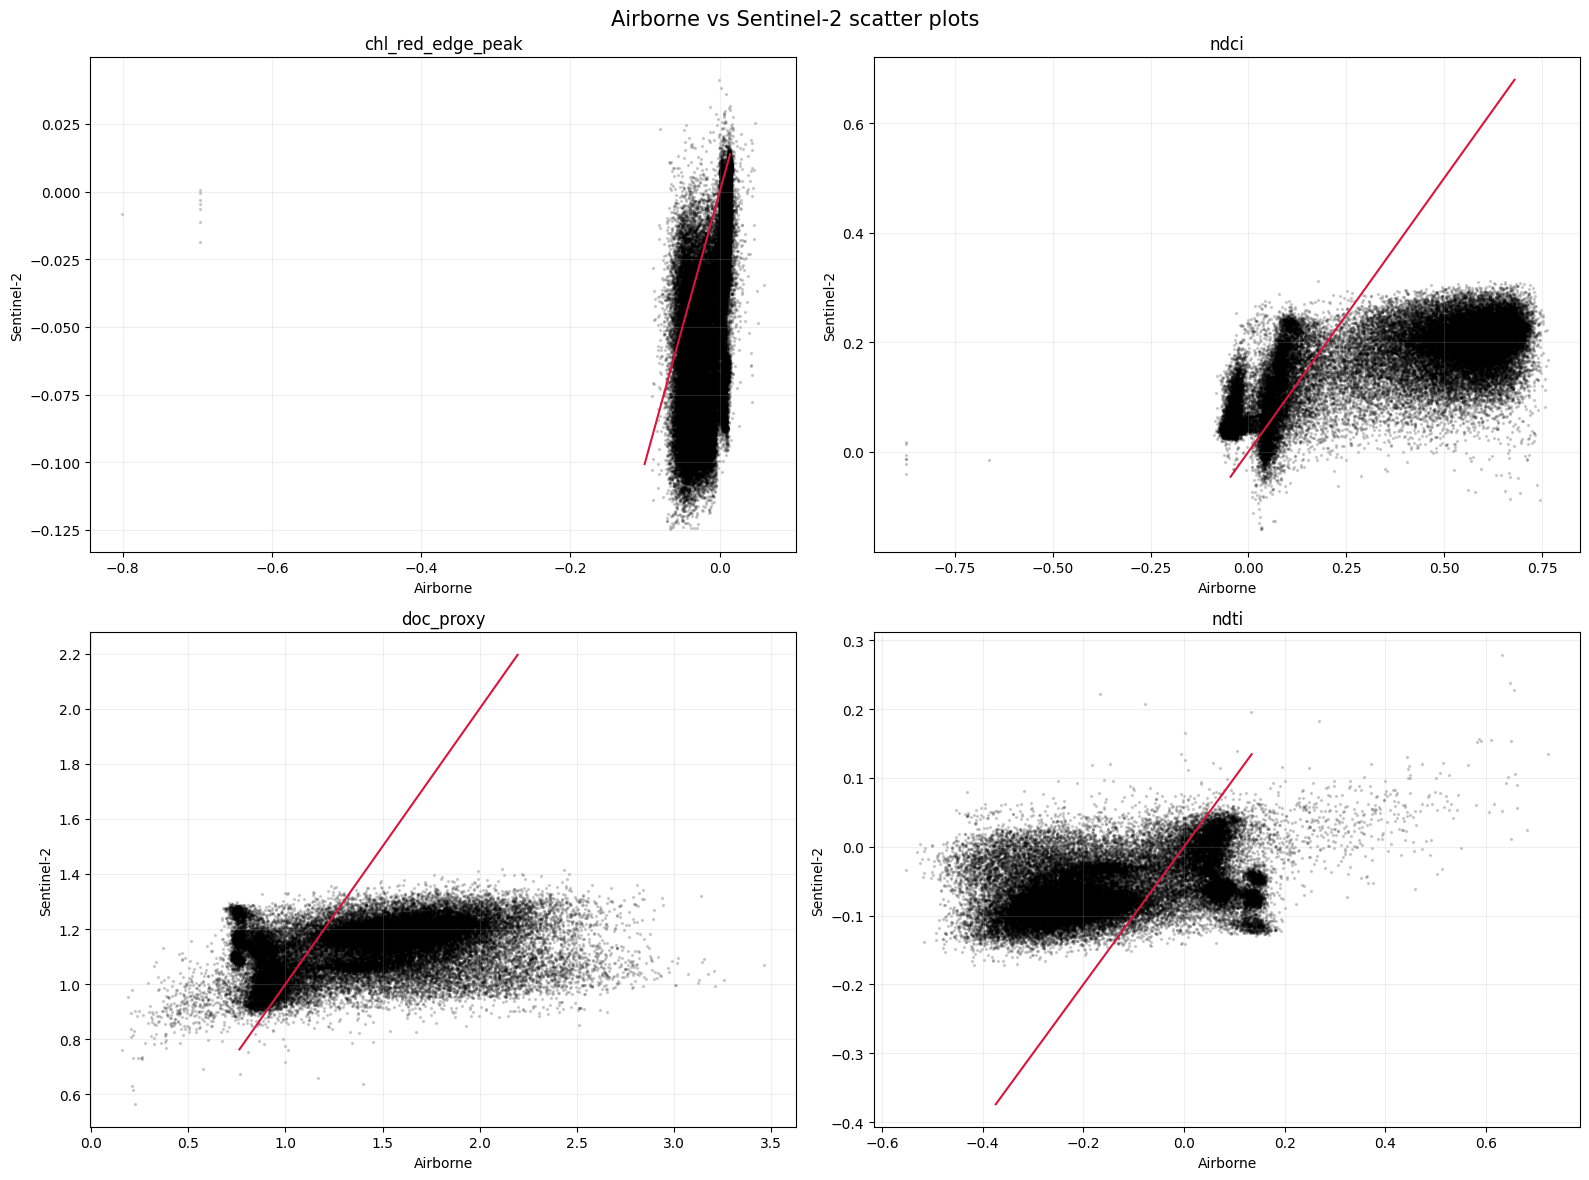

,file,path
0,calibration_params.csv,/Users/ernest.molczan/PycharmProjects/eolabs-c...
1,comparison_histograms.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...
2,comparison_maps.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...
3,comparison_scatter.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...
4,comparison_stats.csv,/Users/ernest.molczan/PycharmProjects/eolabs-c...
5,overlap_mask.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...
6,sam_angle_maps.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...
7,sam_angle_stats.csv,/Users/ernest.molczan/PycharmProjects/eolabs-c...
8,sam_class_counts.csv,/Users/ernest.molczan/PycharmProjects/eolabs-c...
9,sam_classification.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...


Saved comparison outputs to /Users/ernest.molczan/PycharmProjects/eolabs-clone/lab_5/data/outputs/comparison/221000_Odra_HS_Blok_A_008_VS_join_atm


In [69]:
def sample_xy(x: np.ndarray, y: np.ndarray, max_points: int = 50000, seed: int = 42) -> tuple[np.ndarray, np.ndarray]:
    if x.size <= max_points:
        return x, y
    rng = np.random.default_rng(seed)
    sample_idx = rng.choice(x.size, size=max_points, replace=False)
    return x[sample_idx], y[sample_idx]

if not sentinel_products or int(overlap_mask.sum()) == 0:
    comparison_stats = pd.DataFrame()
    print("Skipping comparison outputs because no shared valid overlap is available.")
else:
    output_dir = comparison_output_dir(OUTPUTS_ROOT, SCENE_PATH.stem)
    masked_airborne = {
        name: np.where(overlap_mask, array, np.nan)
        for name, array in airborne_products.items()
    }
    masked_sentinel = {
        name: np.where(overlap_mask, array, np.nan)
        for name, array in sentinel_products.items()
    }

    comparison_stats = pd.DataFrame(
        [
            {"index": name, **summarize_pair(masked_airborne[name], masked_sentinel[name], overlap_mask)}
            for name in masked_airborne
        ]
    )
    comparison_stats.to_csv(output_dir / "comparison_stats.csv", index=False)
    display(comparison_stats)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(overlap_mask, cmap="gray", interpolation="nearest")
    ax.set_title("Airborne and Sentinel-2 overlap mask")
    ax.axis("off")
    plt.tight_layout()
    fig.savefig(output_dir / "overlap_mask.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(len(masked_airborne), 2, figsize=(14, 4 * len(masked_airborne)), subplot_kw={"aspect": "auto"})
    if len(masked_airborne) == 1:
        axes = np.asarray([axes])
    for row_idx, name in enumerate(masked_airborne):
        airborne_array = masked_airborne[name]
        sentinel_array = masked_sentinel[name]
        combined = np.concatenate([airborne_array[overlap_mask], sentinel_array[overlap_mask]])
        lo, hi = finite_limits(combined)

        left = axes[row_idx, 0]
        right = axes[row_idx, 1]

        image_left = left.imshow(airborne_array, cmap=display_cmaps[name], vmin=lo, vmax=hi)
        left.set_title(f"Airborne {name}")
        left.axis("off")
        plt.colorbar(image_left, ax=left, fraction=0.046, pad=0.04)

        image_right = right.imshow(sentinel_array, cmap=display_cmaps[name], vmin=lo, vmax=hi)
        right.set_title(f"Sentinel-2 {name}")
        right.axis("off")
        plt.colorbar(image_right, ax=right, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fig.savefig(output_dir / "comparison_maps.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Airborne vs Sentinel-2 histograms", fontsize=15)
    for ax, name in zip(axes.flat, masked_airborne, strict=True):
        airborne_values = masked_airborne[name][overlap_mask]
        sentinel_values = masked_sentinel[name][overlap_mask]
        ax.hist(airborne_values, bins=60, alpha=0.6, label="Airborne", color="steelblue")
        ax.hist(sentinel_values, bins=60, alpha=0.45, label="Sentinel-2", color="darkorange")
        ax.set_title(name)
        ax.set_xlabel("Value")
        ax.set_ylabel("Pixel count")
        ax.legend()
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    fig.savefig(output_dir / "comparison_histograms.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Airborne vs Sentinel-2 scatter plots", fontsize=15)
    for ax, name in zip(axes.flat, masked_airborne, strict=True):
        airborne_values = masked_airborne[name][overlap_mask]
        sentinel_values = masked_sentinel[name][overlap_mask]
        sample_airborne, sample_sentinel = sample_xy(airborne_values, sentinel_values)
        ax.scatter(sample_airborne, sample_sentinel, s=2, alpha=0.15, color="black")
        combined = np.concatenate([sample_airborne, sample_sentinel])
        lo, hi = finite_limits(combined)
        ax.plot([lo, hi], [lo, hi], color="crimson", linewidth=1.5)
        ax.set_title(name)
        ax.set_xlabel("Airborne")
        ax.set_ylabel("Sentinel-2")
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    fig.savefig(output_dir / "comparison_scatter.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    output_table = pd.DataFrame(
        [{"file": path.name, "path": str(path)} for path in sorted(output_dir.iterdir())]
    )
    display(output_table)
    print(f"Saved comparison outputs to {output_dir}")


## Spectral Library References

This section loads the spectral-library summaries that were exported from the
viewer ROI workflow and rebuilt into per-class mean spectra. Those summaries are
the reference input for both airborne SAM and calibrated Sentinel-2 SAM.


,class_name,sample_count,wavelength_count,summary_path
0,bare soil,2,456,/Users/ernest.molczan/PycharmProjects/eolabs-c...
1,vegetation,3,456,/Users/ernest.molczan/PycharmProjects/eolabs-c...
2,water,4,456,/Users/ernest.molczan/PycharmProjects/eolabs-c...


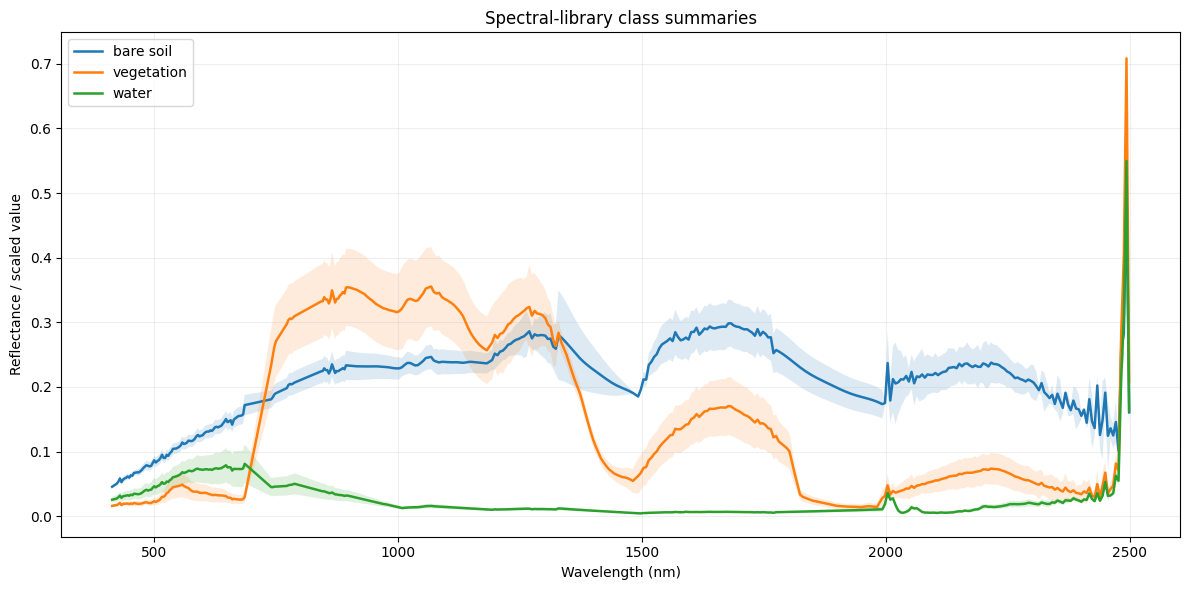

In [70]:
reference_library = load_library_summaries(SPECTRAL_LIBRARY_DIR)

if not reference_library:
    reference_table = pd.DataFrame()
    print("No spectral-library summaries found. Export ROI samples from viewer.py and rebuild the library before running the SAM section.")
else:
    reference_table = pd.DataFrame(
        [
            {
                "class_name": class_name,
                "sample_count": reference["sample_count"],
                "wavelength_count": int(reference["wavelengths"].size),
                "summary_path": str(reference["summary_path"]),
            }
            for class_name, reference in reference_library.items()
        ]
    )
    display(reference_table)

    fig, ax = plt.subplots(figsize=(12, 6))
    for class_name, reference in reference_library.items():
        mean_spectrum = np.asarray(reference["mean_spectrum"], dtype=np.float64)
        std_spectrum = np.asarray(reference["std_spectrum"], dtype=np.float64)
        ax.plot(reference["wavelengths"], mean_spectrum, linewidth=1.8, label=class_name)
        if np.any(np.isfinite(std_spectrum)):
            spread = np.nan_to_num(std_spectrum, nan=0.0)
            ax.fill_between(
                reference["wavelengths"],
                mean_spectrum - spread,
                mean_spectrum + spread,
                alpha=0.15,
            )
    ax.set_title("Spectral-library class summaries")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Reflectance / scaled value")
    ax.grid(True, alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()


## Calibration And Reference Resampling

Before running SAM on Sentinel-2, the airborne references are resampled to the
Sentinel-2 band set and a per-band gain/offset calibration is fit over the valid
overlap between the airborne scene and the Sentinel-2 stack.


In [71]:
# Do not filter by invalid_mask — use the actual 705/740/865 nm bands for
# calibration against Sentinel-2 B05/B06/B8A.
airborne_s2_band_stack = {
    "B02": band_by_wavelength(img, wavelengths, 490, ignore_value=ignore_value),
    "B03": band_by_wavelength(img, wavelengths, 560, ignore_value=ignore_value),
    "B04": band_by_wavelength(img, wavelengths, 665, ignore_value=ignore_value),
    "B05": band_by_wavelength(img, wavelengths, 705, ignore_value=ignore_value),
    "B06": band_by_wavelength(img, wavelengths, 740, ignore_value=ignore_value),
    "B07": band_by_wavelength(img, wavelengths, 783, ignore_value=ignore_value),
    "B08": band_by_wavelength(img, wavelengths, 842, ignore_value=ignore_value),
    "B8A": band_by_wavelength(img, wavelengths, 865, ignore_value=ignore_value),
    "B11": band_by_wavelength(img, wavelengths, 1610, ignore_value=ignore_value),
    "B12": band_by_wavelength(img, wavelengths, 2190, ignore_value=ignore_value),
}
sam_output_dir = comparison_output_dir(OUTPUTS_ROOT, SCENE_PATH.stem)

if not reference_library or not s2_reflectance or int(overlap_mask.sum()) == 0:
    calibration_params = {}
    calibration_table = pd.DataFrame()
    resampled_reference_table = pd.DataFrame()
    sentinel_calibrated_stack = {}
    airborne_reference_spectra = {}
    sentinel_reference_spectra = {}
    print("Skipping calibration because references or Sentinel-2 overlap are unavailable.")
else:
    airborne_reference_spectra = {}
    sentinel_reference_spectra = {}
    for class_name, reference in reference_library.items():
        airborne_reference = align_reference_to_wavelengths(
            reference["mean_spectrum"],
            reference["wavelengths"],
            wavelengths,
        )
        airborne_reference_spectra[class_name] = airborne_reference
        sentinel_reference_spectra[class_name] = resample_airborne_spectrum_to_s2(
            reference["mean_spectrum"],
            reference["wavelengths"],
        )

    calibration_params = fit_bandwise_linear_calibration(
        airborne_s2_band_stack,
        s2_reflectance,
        overlap_mask,
    )
    calibration_table = pd.DataFrame(
        [
            {"band": band_name, **params}
            for band_name, params in calibration_params.items()
        ]
    )
    resampled_reference_table = pd.DataFrame(
        [
            {
                "class_name": class_name,
                **{
                    band_name: float(sentinel_reference_spectra[class_name][band_idx])
                    for band_idx, band_name in enumerate(SENTINEL2_SAM_BANDS)
                },
            }
            for class_name in sentinel_reference_spectra
        ]
    )
    sentinel_calibrated_stack = apply_bandwise_linear_calibration(s2_reflectance, calibration_params)

    calibration_table.to_csv(sam_output_dir / "calibration_params.csv", index=False)
    resampled_reference_table.to_csv(sam_output_dir / "sam_resampled_references.csv", index=False)
    display(calibration_table)
    display(resampled_reference_table)


,band,gain,offset,valid_pixels,fit_pixels,method,rmse_before,rmse_after
0,B02,0.502441,-0.038181,3174220,3056608,gain_offset,0.114453,0.030987
1,B03,0.502101,-0.023937,3174220,3058088,gain_offset,0.114505,0.037824
2,B04,0.475039,-0.018661,3174220,3058371,gain_offset,0.109519,0.047006
3,B05,0.480135,0.004753,3174220,3056140,gain_offset,0.114366,0.045727
4,B06,0.630048,-0.037980,3174220,3057325,gain_offset,0.190526,0.085686
5,B07,0.671280,-0.035339,3174220,3057670,gain_offset,0.202580,0.112652
6,B08,0.726503,-0.049250,3174220,3063780,gain_offset,0.201160,0.117410
7,B8A,0.776821,-0.061723,3174220,3063171,gain_offset,0.200424,0.127982
8,B11,0.794425,-0.072127,3174220,3064610,gain_offset,0.149595,0.079336
9,B12,0.552208,-0.030133,3174220,3059290,gain_offset,0.133492,0.062229


,class_name,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12
0,bare soil,0.077255,0.112574,0.150177,0.174977,0.180799,0.204390,0.223915,0.234682,0.289148,0.231201
1,vegetation,0.020370,0.047448,0.026587,0.101638,0.233257,0.305818,0.332008,0.348989,0.155796,0.069299
2,water,0.040172,0.067304,0.073073,0.068287,0.045023,0.048830,0.039122,0.036553,0.006412,0.011092


## SAM Angle Maps And Classification

The final section runs SAM on the full airborne cube using the saved class
summaries, then applies the same class library to the calibrated Sentinel-2
stack. The plots below compare per-class angle maps and the final class maps over
the overlapping footprint.


,class_name,valid_pixels,airborne_mean,sentinel_mean,bias_s2_minus_airborne,mae,rmse,pearson_r
0,bare soil,3174220,0.631661,0.418601,-0.213059,0.264826,0.337200,0.200434
1,vegetation,3174220,0.447409,0.195021,-0.252387,0.267159,0.340075,0.762519
2,water,3174220,0.926642,0.726317,-0.200325,0.239579,0.268460,0.751709


,class_name,airborne_pixels,sentinel_pixels
0,bare soil,596629,542153
1,vegetation,1995897,2385653
2,water,581694,246414


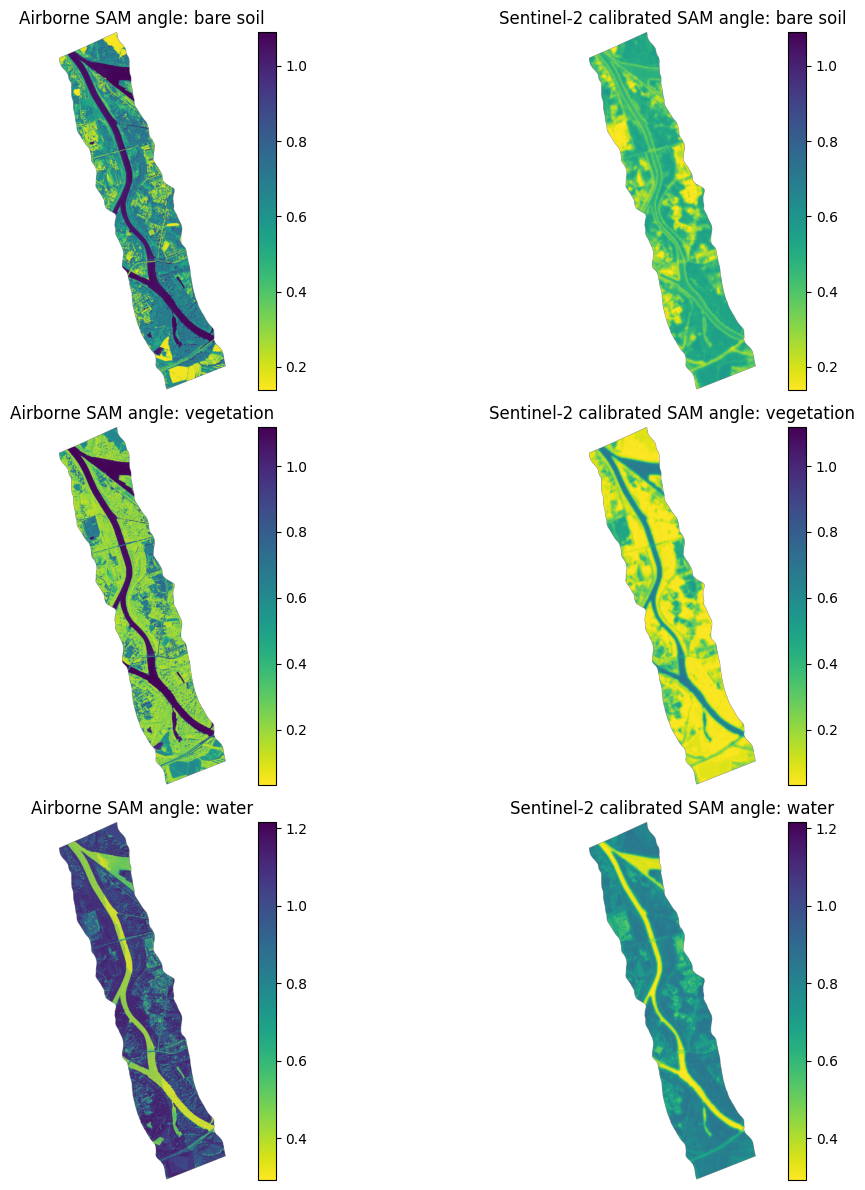

/var/folders/5n/vhp5y1js2pg5w41k63tkv7th0000gn/T/ipykernel_56283/3952280099.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  class_cmap = plt.cm.get_cmap("tab10", n_classes + 1)


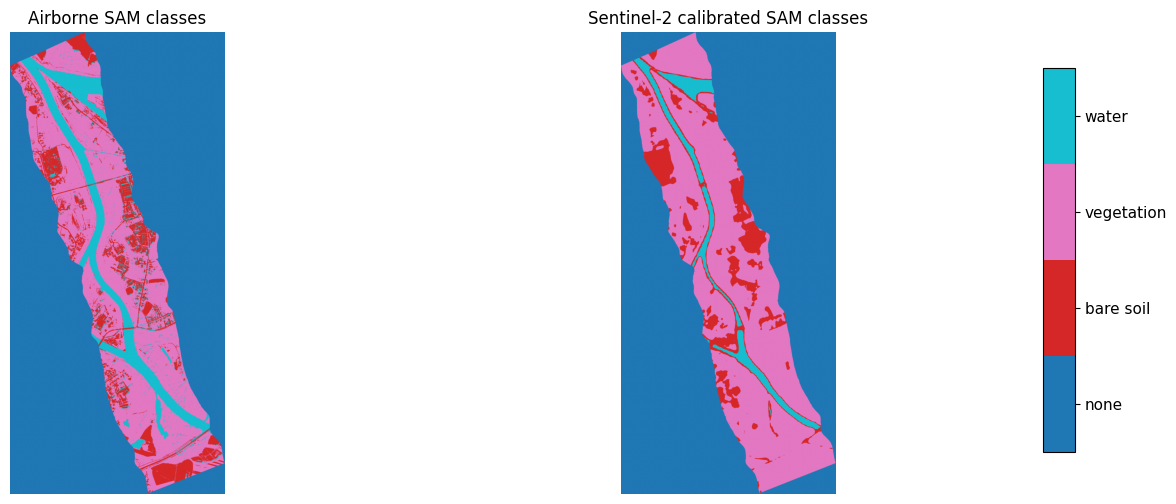

,file,path
0,calibration_params.csv,/Users/ernest.molczan/PycharmProjects/eolabs-c...
1,sam_angle_maps.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...
2,sam_angle_stats.csv,/Users/ernest.molczan/PycharmProjects/eolabs-c...
3,sam_class_counts.csv,/Users/ernest.molczan/PycharmProjects/eolabs-c...
4,sam_classification.png,/Users/ernest.molczan/PycharmProjects/eolabs-c...
5,sam_resampled_references.csv,/Users/ernest.molczan/PycharmProjects/eolabs-c...


Saved SAM outputs to /Users/ernest.molczan/PycharmProjects/eolabs-clone/lab_5/data/outputs/comparison/221000_Odra_HS_Blok_A_008_VS_join_atm


In [72]:
if not airborne_reference_spectra or not sentinel_calibrated_stack or int(overlap_mask.sum()) == 0:
    sam_angle_stats = pd.DataFrame()
    sam_class_counts = pd.DataFrame()
    print("Skipping SAM outputs because references, calibration, or overlap data are unavailable.")
else:
    airborne_cube = img.open_memmap(interleave="bip")
    airborne_angle_maps = {
        class_name: spectral_angle_image(
            airborne_reference_spectra[class_name],
            airborne_cube,
            ignore_value=ignore_value,
            invalid_mask=invalid_mask,
            pixel_mask=overlap_mask,
            chunk_rows=16,
        )
        for class_name in airborne_reference_spectra
    }
    sentinel_calibrated_array = stack_named_bands(sentinel_calibrated_stack, SENTINEL2_SAM_BANDS)
    sentinel_angle_maps = {
        class_name: spectral_angle_image(
            sentinel_reference_spectra[class_name],
            sentinel_calibrated_array,
            pixel_mask=overlap_mask,
            chunk_rows=256,
        )
        for class_name in sentinel_reference_spectra
    }

    airborne_sam = sam_classification(airborne_angle_maps)
    sentinel_sam = sam_classification(sentinel_angle_maps)
    sam_angle_stats = pd.DataFrame(
        [
            {"class_name": class_name, **summarize_pair(airborne_angle_maps[class_name], sentinel_angle_maps[class_name], overlap_mask)}
            for class_name in airborne_angle_maps
        ]
    )
    sam_class_counts = pd.DataFrame(
        [
            {
                "class_name": class_name,
                "airborne_pixels": int(np.sum(airborne_sam["class_index"] == idx)),
                "sentinel_pixels": int(np.sum(sentinel_sam["class_index"] == idx)),
            }
            for idx, class_name in enumerate(airborne_sam["class_names"], start=1)
        ]
    )

    sam_angle_stats.to_csv(sam_output_dir / "sam_angle_stats.csv", index=False)
    sam_class_counts.to_csv(sam_output_dir / "sam_class_counts.csv", index=False)
    display(sam_angle_stats)
    display(sam_class_counts)

    fig, axes = plt.subplots(len(airborne_angle_maps), 2, figsize=(14, 4 * len(airborne_angle_maps)), subplot_kw={"aspect": "auto"})
    if len(airborne_angle_maps) == 1:
        axes = np.asarray([axes])
    for row_idx, class_name in enumerate(airborne_angle_maps):
        airborne_angle = np.where(overlap_mask, airborne_angle_maps[class_name], np.nan)
        sentinel_angle = np.where(overlap_mask, sentinel_angle_maps[class_name], np.nan)
        combined = np.concatenate([airborne_angle[overlap_mask], sentinel_angle[overlap_mask]])
        lo, hi = finite_limits(combined)

        left = axes[row_idx, 0]
        right = axes[row_idx, 1]

        image_left = left.imshow(airborne_angle, cmap="viridis_r", vmin=lo, vmax=hi)
        left.set_title(f"Airborne SAM angle: {class_name}")
        left.axis("off")
        plt.colorbar(image_left, ax=left, fraction=0.046, pad=0.04)

        image_right = right.imshow(sentinel_angle, cmap="viridis_r", vmin=lo, vmax=hi)
        right.set_title(f"Sentinel-2 calibrated SAM angle: {class_name}")
        right.axis("off")
        plt.colorbar(image_right, ax=right, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fig.savefig(sam_output_dir / "sam_angle_maps.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    air_classes = np.where(overlap_mask, airborne_sam["class_index"], 0)
    s2_classes = np.where(overlap_mask, sentinel_sam["class_index"], 0)
    n_classes = len(airborne_sam["class_names"])
    class_cmap = plt.cm.get_cmap("tab10", n_classes + 1)
    class_vmin = -0.5
    class_vmax = n_classes + 0.5

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        subplot_kw={"aspect": "auto"},
        gridspec_kw={"wspace": 0.08},
    )
    image_left = axes[0].imshow(air_classes, cmap=class_cmap, vmin=class_vmin, vmax=class_vmax)
    axes[0].set_title("Airborne SAM classes")
    axes[0].axis("off")

    image_right = axes[1].imshow(s2_classes, cmap=class_cmap, vmin=class_vmin, vmax=class_vmax)
    axes[1].set_title("Sentinel-2 calibrated SAM classes")
    axes[1].axis("off")

    fig.subplots_adjust(right=0.86)
    cax = fig.add_axes([0.88, 0.18, 0.02, 0.64])
    cbar = fig.colorbar(image_right, cax=cax, ticks=np.arange(n_classes + 1))
    cbar.ax.set_yticklabels(["none"] + airborne_sam["class_names"])
    cbar.ax.tick_params(labelsize=11)
    fig.savefig(sam_output_dir / "sam_classification.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    sam_output_table = pd.DataFrame(
        [
            {"file": path.name, "path": str(path)}
            for path in sorted(sam_output_dir.iterdir())
            if path.name.startswith("sam_") or path.name == "calibration_params.csv"
        ]
    )
    display(sam_output_table)
    print(f"Saved SAM outputs to {sam_output_dir}")
